In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import anderson_ksamp
import mlflow
import torch
from torch import nn, optim
import torch.utils.data as data_utils
from IPython.display import clear_output
from pytorch_lightning import Trainer
from pytorch_lightning.utilities.seed import seed_everything
from pytorch_lightning.callbacks import Callback
import yaml

from genhack.dataset import StationsDataset
from genhack.models import models
from genhack.experiment import Experiment
from genhack.utils import *


In [3]:
df = pd.read_csv('data/df_train.csv')
df = df.set_index('dates')

In [4]:
params = np.load('parameters/example_params.npy')
noise = np.load('data/noise.npy')

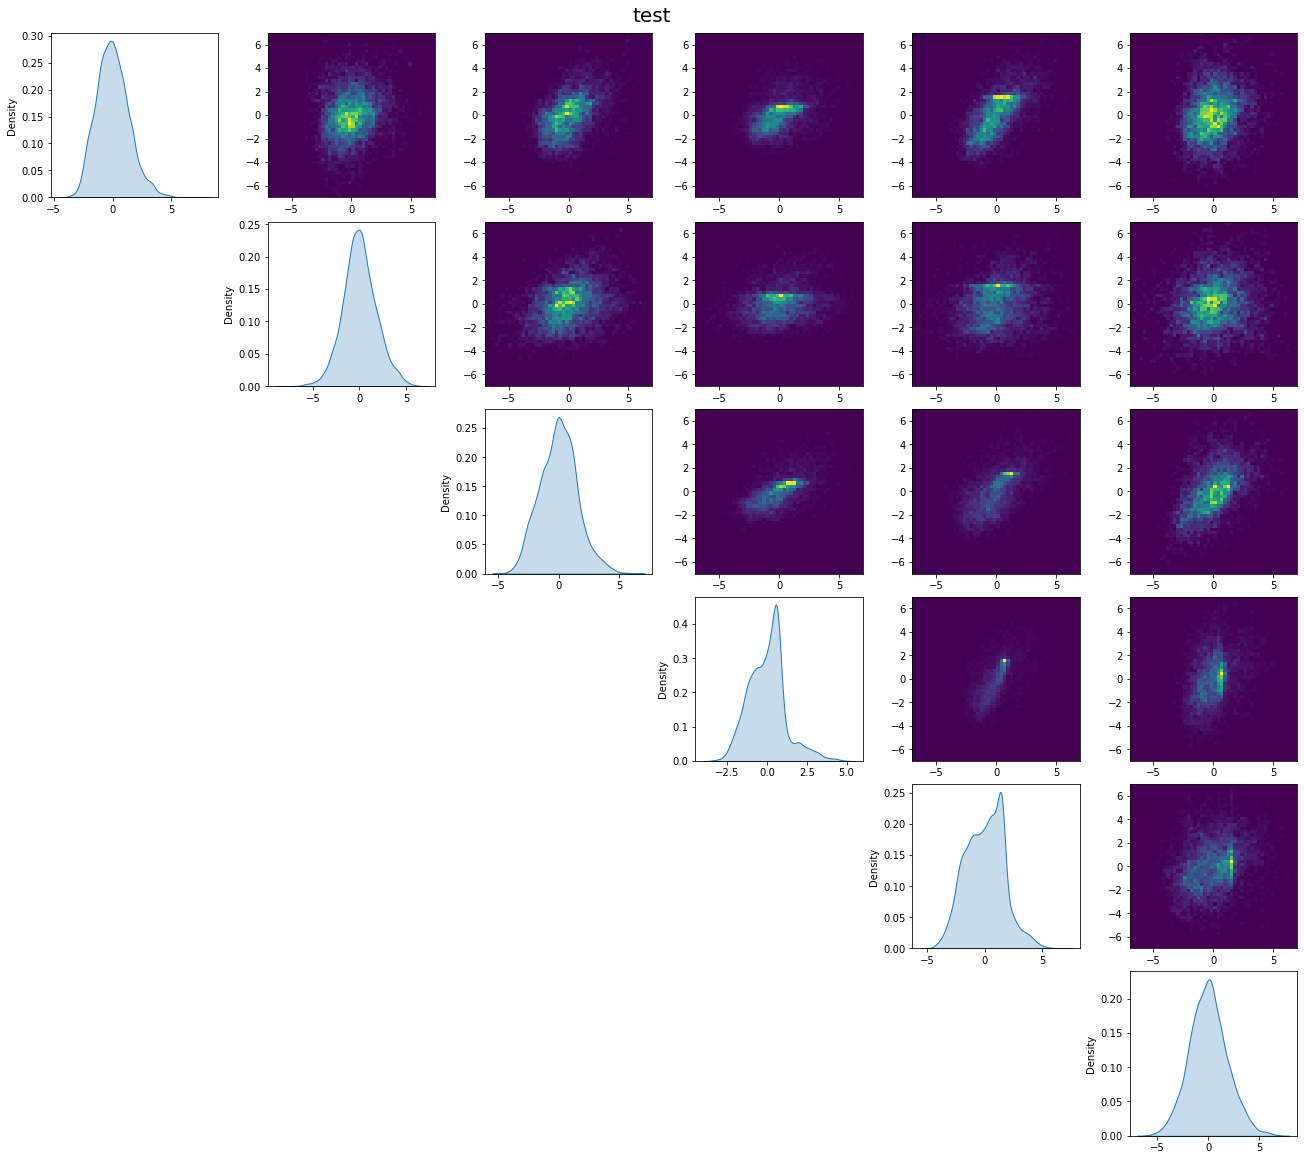

In [5]:
fig, ax = plt.subplots(nrows=6, ncols=6, figsize=(18, 16), constrained_layout=True)
fig.suptitle('test', fontsize=20)

for i in range(6):
    for j in range(6):
        if i < j:
            ax[i][j].hist2d(df[f's{i+1}'], df[f's{j+1}'], bins=50, range=[[-7, 7], [-7, 7]])
        if i > j:
            fig.delaxes(ax[i][j])
    sns.kdeplot(data=df.to_numpy()[:, i], ax=ax[i][i], fill=True)


# Train

In [17]:
from hyperopt import hp, fmin, tpe, space_eval


In [ ]:
order = np.sort(df.to_numpy(), axis=0)
idx = np.floor(norm.cdf(torch.torch.randn(2000, 6)) * len(order)).astype(int)
samples = np.array([[order[idx[i][j]][j] for j in range(idx.shape[1])] for i in range(idx.shape[0])])

<AxesSubplot:ylabel='Density'>

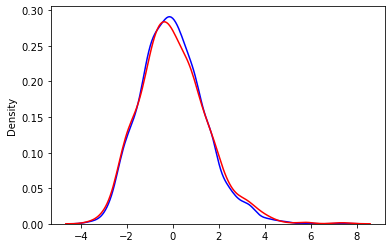

In [163]:
fig, ax = plt.subplots()
sns.kdeplot(order[:, 0], ax=ax, c='b')
sns.kdeplot(samples[:, 0], ax=ax, c='r')

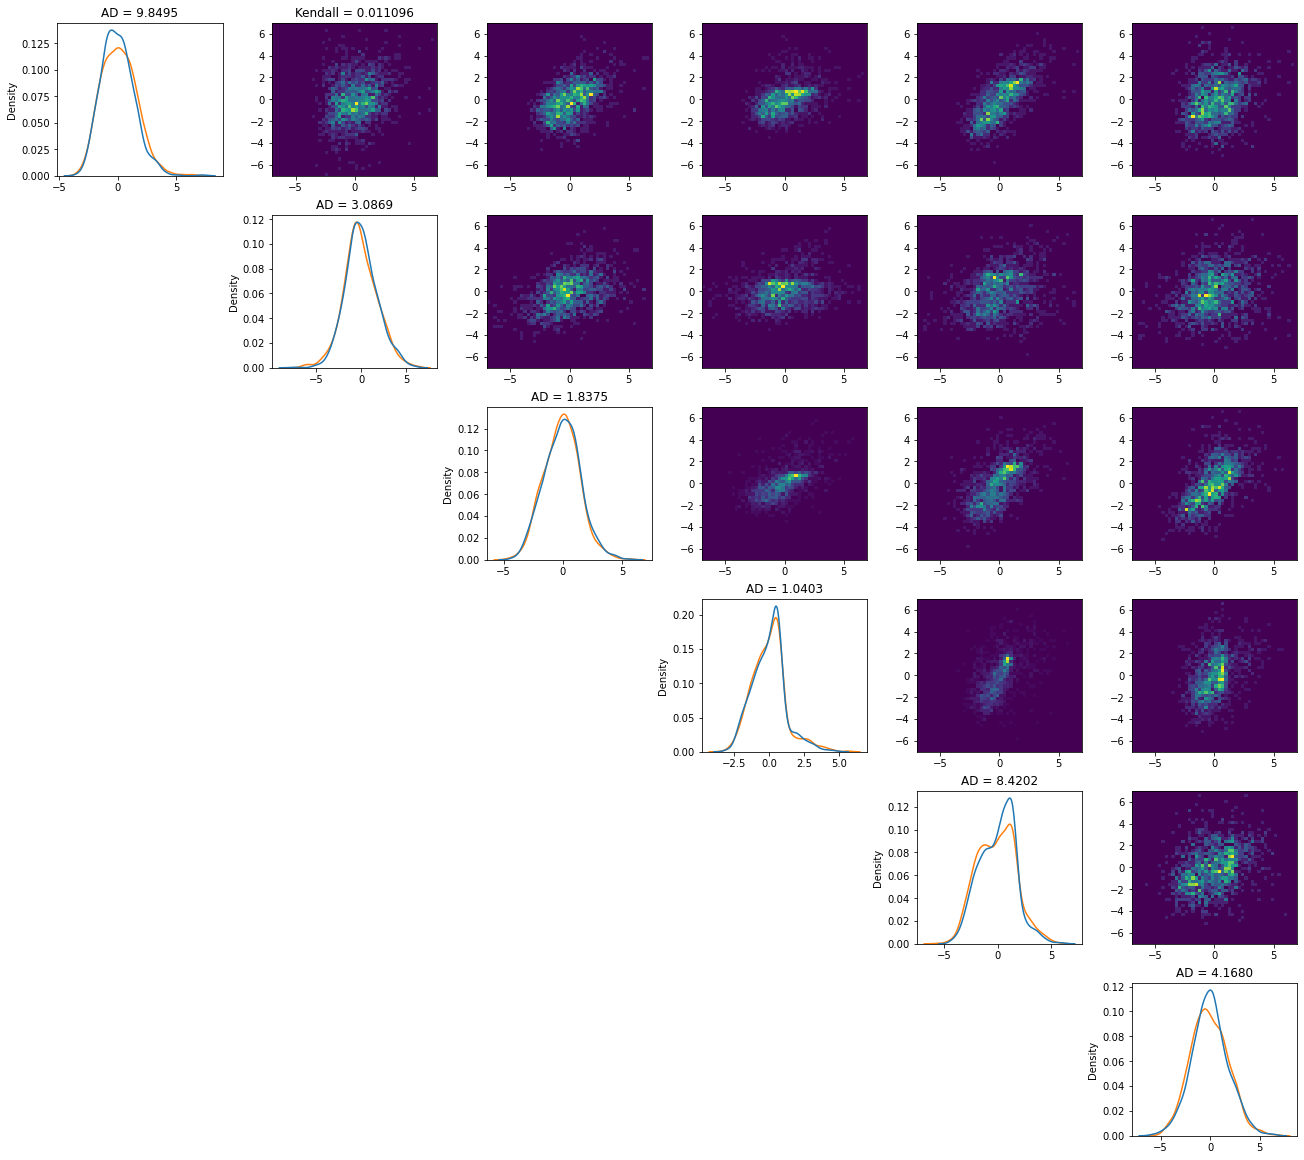

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch: 100/100


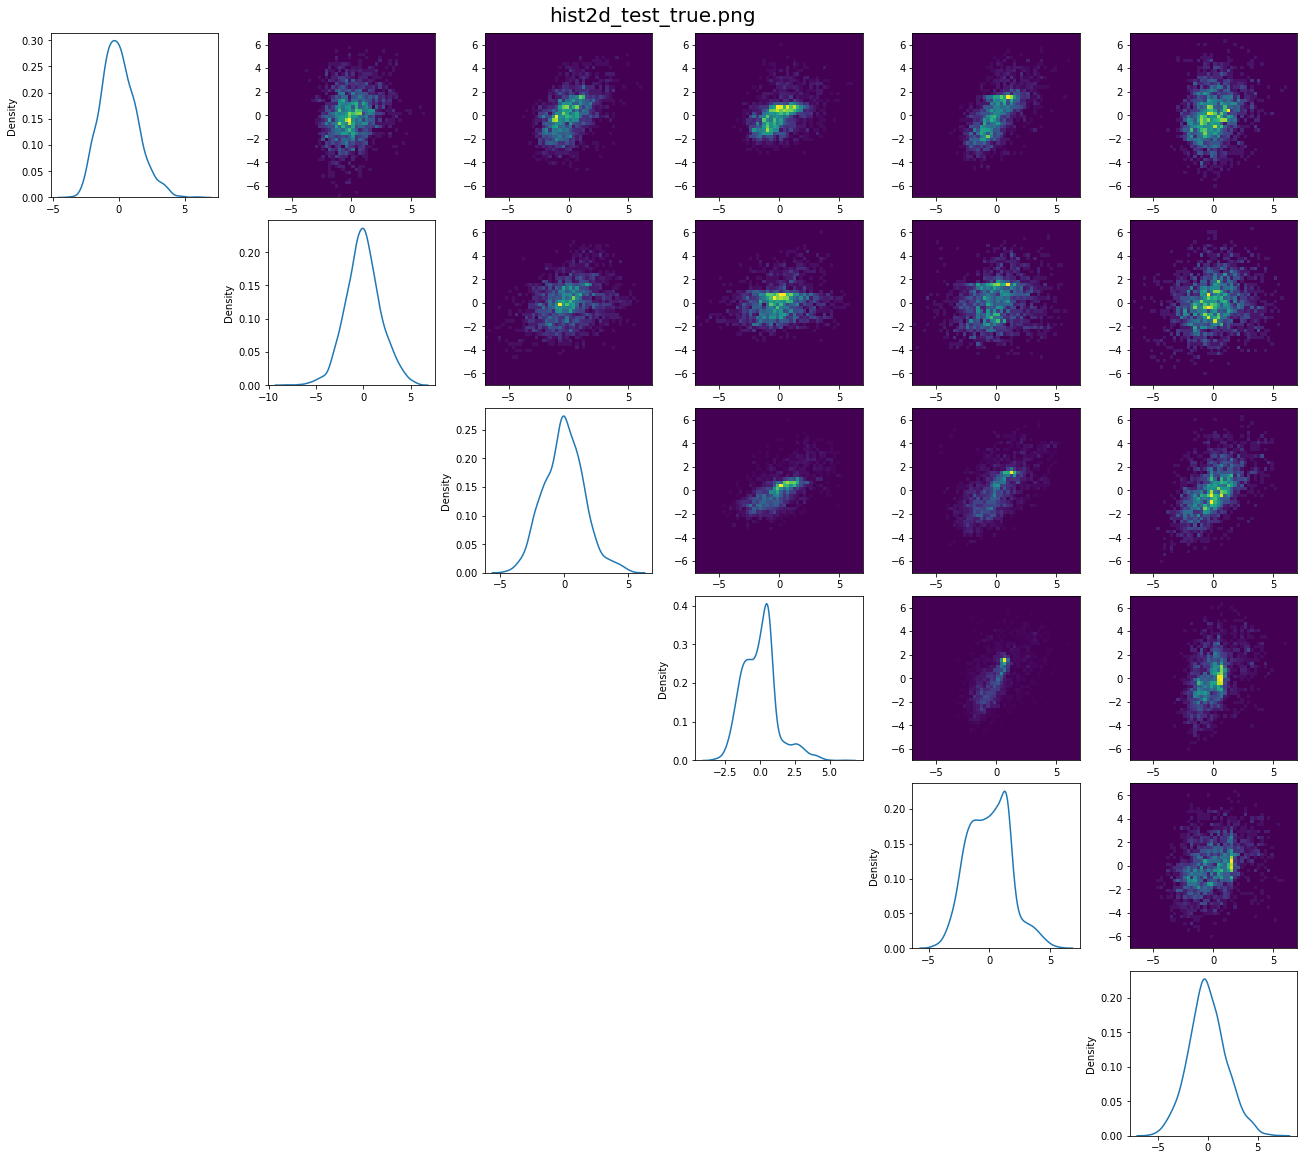

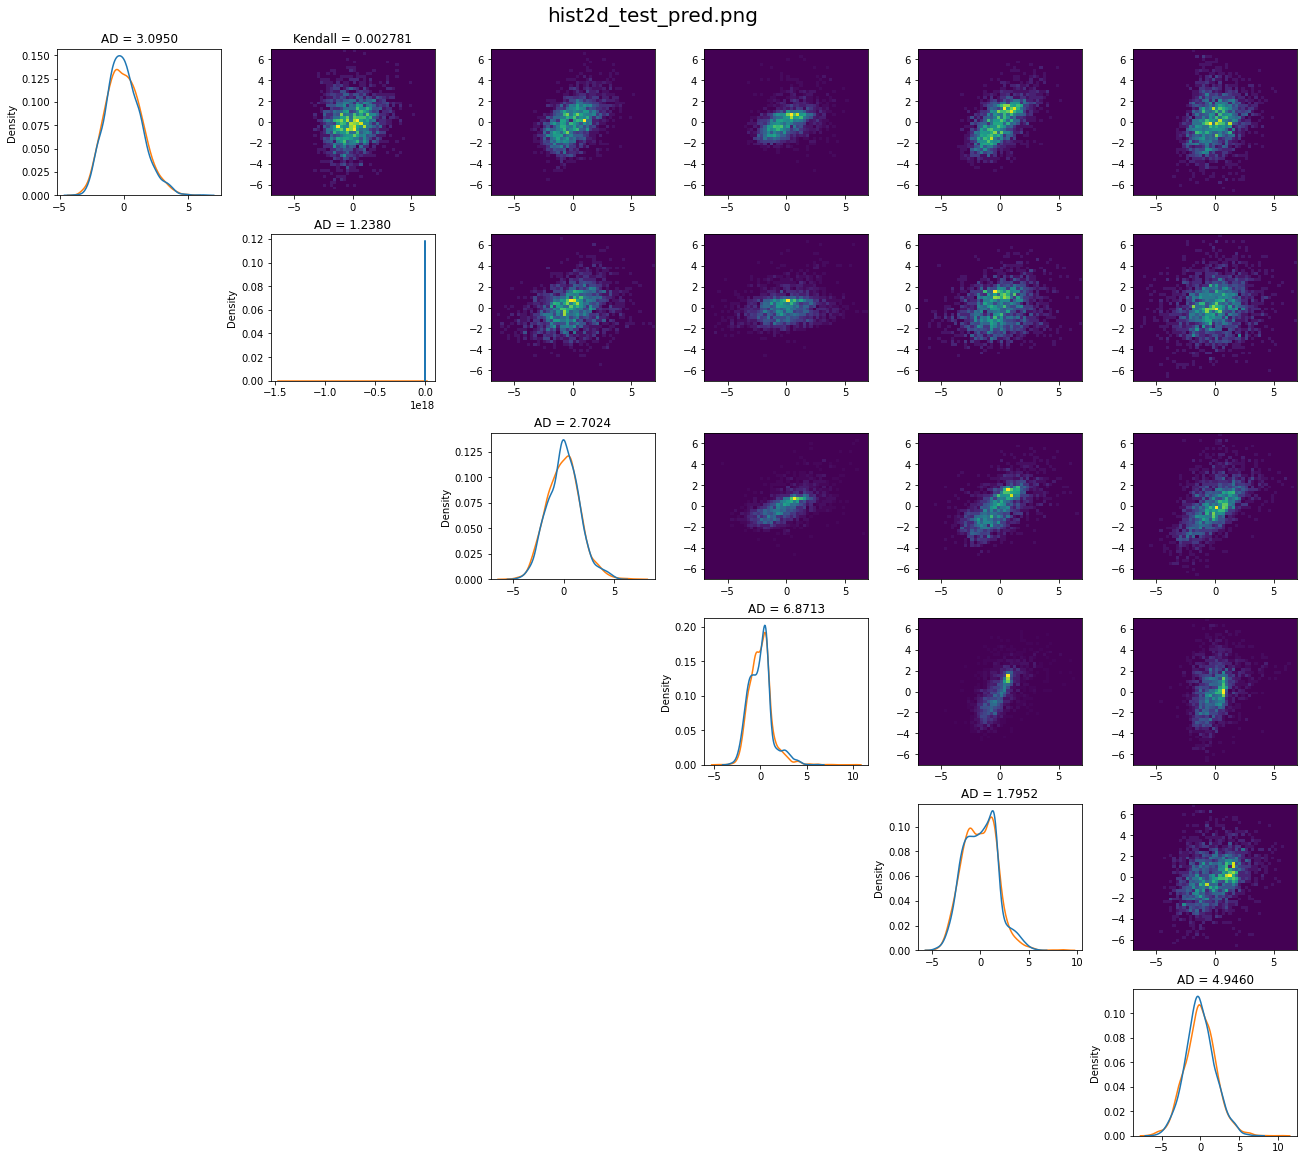

In [15]:
with open('configs/maf.yaml', 'r') as file:
    try:
        config = yaml.safe_load(file)
    except yaml.YAMLError as exc:
        print(exc)

class HistCallback(Callback):
    def on_validation_start(self, trainer, pl_module):
        X_val = trainer.datamodule.val_dataset[:][0]
        X_val_pred = trainer.model.model.sample(len(X_val))
        fig = plot_hist2d(X_val_pred, X_val)
        clear_output(wait=True)
        plt.show()
        print(f"Epoch: {trainer.current_epoch+1}/{trainer.max_epochs}")

seed_everything(config['experiment_params']['manual_seed'], True)

datamodule = StationsDataset(**config['data_params'])
model = models[config['model_params']['name']](**config['model_params'], datamodule=datamodule)
experiment = Experiment(model, config.get('experiment_params', None))
trainer = Trainer(callbacks=[HistCallback()], enable_progress_bar=False, **config['trainer_params'])

mlflow.pytorch.autolog(log_models=False)

with mlflow.start_run() as run:
    for name in 'model_params', 'experiment_params', 'data_params', 'trainer_params':
        if name in config:
            mlflow.log_params(config[name])
    trainer.fit(experiment, datamodule=datamodule)
    experiment.test_step(datamodule.test_dataset[:], 0)
